In [1]:
import pandas as pd
import numpy as np
import warnings
from pathlib import Path
import sys
import os
from datetime import datetime

project_root = Path.cwd()
while not (project_root / "src").exists():
    project_root = project_root.parent
project_root_str = str(project_root)

if project_root_str not in sys.path:
    sys.path.insert(0, project_root_str)

os.chdir(project_root_str)

from src.utils.team_info import *
from src.historical_analysis.dataScraper import *

warnings.filterwarnings("ignore")
pd.set_option('display.max_columns', None)

In [2]:
import joblib

project_root = Path("/Users/alexgonzalez/Documents/NBA-Prop-Predictor")  # or Path.cwd()
min_path = project_root / "src/models/saved_models/min_quantile_xgb_2026-02-03.joblib"
ppm_path = project_root / "src/models/saved_models/ppm_quantile_xgb_2026-02-02.joblib"

min_bundle = joblib.load(min_path)
min_models = min_bundle["quantile_models"]
min_feature_names = min_bundle["feature_names"]

ppm_bundle = joblib.load(ppm_path)
ppm_models = ppm_bundle["quantile_models"]
ppm_feature_names = ppm_bundle["feature_names"]


#load season stats
pts_df = pd.read_csv('data/processed/training/S26_TRAINING_PPM.csv')
ast_df = pd.read_csv('data/processed/training/S26_TRAINING_APM.csv')
reb_df = pd.read_csv('data/processed/training/S26_TRAINING_RPM.csv')
min_df = pd.read_csv('data/processed/training/S26_TRAINING_MIN.csv')

### Solo lookup

In [16]:
def grab_player_last_game(df, features, player, date):
    pdf = df[(df['PLAYER_NAME'] == player) & (df['GAME_DATE'] == date)]
    if pdf.empty:
        return f"No data found for {player} on {date}"
    return pdf[features]
player = 'Shai Gilgeous-Alexander'
last_mins = grab_player_last_game(min_df, min_feature_names, player, '2026-04-02')
last_ppm = grab_player_last_game(pts_df, ppm_feature_names, player, '2026-04-02')

min_arr = np.asarray(last_mins, dtype=float).reshape(1, -1)
ppm_arr = np.asarray(last_ppm, dtype=float).reshape(1, -1)

min_pred = min_models['q_0.50'].predict(min_arr)
ppm_pred = ppm_models['q_0.50'].predict(ppm_arr)
print(f"predicted MIN: {min_pred[0]:.2f}, predicted PPM: {ppm_pred[0]:.2f}, predicted PTS: {min_pred[0] * ppm_pred[0]:.2f}")
last_mins

predicted MIN: 35.36, predicted PPM: 0.92, predicted PTS: 32.63


,GP,STARTING,STARTING_lag1,STARTER_ROLL10_PCT,MIN_ewm_season_avg,TEAM_MIN_RANK_L10,MIN_10_ewm,MIN_lag1,ROLE_LOCK,TEAM_USG_RANK_L10,MIN_ROLE_Z_SCORE,POSS_10_ewm,MIN_MAX_L10,MIN_MIN_L10,MIN_SEASON_STD
85243,64,1.0,1.0,1.0,35.56,1.0,34.63,40.533333,0.207469,1.0,0.062218,71.31,40.533333,25.566667,4.33333


### Week lookup 

In [5]:
date = '2026-03-18'

backtest_df = pd.read_csv(f'/Users/alexgonzalez/Documents/NBA-Prop-Predictor/data/backtest/historical_odds/{date}.csv')
backtest_df = backtest_df[backtest_df['prop'] == 'Points']

res = []

for player in backtest_df['player']:
    pdf_pts_mean = pts_df[(pts_df['PLAYER_NAME'] == player)]['PTS'].mean()
    pdf = pts_df[(pts_df['PLAYER_NAME'] == player) & (pts_df['GAME_DATE'] == date)]
    if pdf.empty:
        print(f"No data found for {player} on {date}")
        continue
    last_mins = grab_player_last_game(min_df, min_feature_names, player, date)
    last_ppm = grab_player_last_game(pts_df, ppm_feature_names, player, date)
    if not isinstance(last_mins, pd.DataFrame) or not isinstance(last_ppm, pd.DataFrame):
        continue
    line = backtest_df[backtest_df['player'] == player]['line'].values[0]
    actual_pts = pts_df[(pts_df['PLAYER_NAME'] == player) & (pts_df['GAME_DATE'] == date)]['PTS'].values[0]
    actual_min = pts_df[(pts_df['PLAYER_NAME'] == player) & (pts_df['GAME_DATE'] == date)]['MIN'].values[0]

    min_arr = np.asarray(last_mins, dtype=float).reshape(1, -1)
    ppm_arr = np.asarray(last_ppm, dtype=float).reshape(1, -1)
    min_pred_q50 = min_models['q_0.50'].predict(min_arr)
    ppm_pred_q50 = ppm_models['q_0.50'].predict(ppm_arr)
    pred_q50 = float(min_pred_q50[0] * ppm_pred_q50[0])
    min_pred_q90 = min_models['q_0.90'].predict(min_arr)
    ppm_pred_q90 = ppm_models['q_0.90'].predict(ppm_arr)
    pred_q90 = float(min_pred_q90[0] * ppm_pred_q90[0])
    side_q50 = 'Over' if pred_q50 > line else 'Under'
    side_q90 = 'Over' if pred_q90 > line else 'Under'
    hit_q50 = (side_q50 == "Over" and actual_pts > line) or (side_q50 == "Under" and actual_pts < line)
    hit_q90 = (side_q90 == "Over" and actual_pts > line) or (side_q90 == "Under" and actual_pts < line)
    res.append({
        'player': player,
        'player_pts_mean': pdf_pts_mean,
        'pred points q50': pred_q50,
        'pred points q90': pred_q90,
        'side q50': side_q50,
        'side q90': side_q90,
        'line': line,
        'actual points': actual_pts,
        'error q50': abs(pred_q50 - actual_pts),
        'error q90': abs(pred_q90 - actual_pts),
        'hit q50': int(hit_q50),
        'hit q90': int(hit_q90)
    })
res = pd.DataFrame(res)
print('-' * 100)
print(f"Total hit rate q50: {round(res['hit q50'].sum() / len(res), 2)}")
print(f"Total hit rate q90: {round(res['hit q90'].sum() / len(res), 2)}")
res.head(20)

No data found for Andrew Nembhard on 2026-03-18
No data found for Kristaps Porzingis on 2026-03-18
No data found for P.J. Washington Jr. on 2026-03-18
No data found for GG Jackson II on 2026-03-18
No data found for Bruce Brown Jr. on 2026-03-18
----------------------------------------------------------------------------------------------------
Total hit rate q50: 0.45
Total hit rate q90: 0.47


,player,player_pts_mean,pred points q50,pred points q90,side q50,side q90,line,actual points,error q50,error q90,hit q50,hit q90
0,Jaylen Brown,25.202952,27.465878,39.558212,Over,Over,24.5,32,4.534122,7.558212,1,1
1,Sandro Mamukelashvili,7.526087,8.038298,18.263943,Under,Over,8.5,17,8.961702,1.263943,0,1
2,Neemias Queta,7.321637,10.660348,22.575474,Over,Over,9.5,8,2.660348,14.575474,0,0
3,Tari Eason,10.352941,11.387574,22.696997,Over,Over,10.5,10,1.387574,12.696997,0,0
4,LeBron James,24.914062,20.544039,32.492371,Over,Over,18.5,30,9.455961,2.492371,1,1
5,Deandre Ayton,15.367521,11.015784,22.753862,Over,Over,9.5,16,4.984216,6.753862,1,1
6,RJ Barrett,20.008130,21.176086,33.314251,Under,Over,21.5,23,1.823914,10.314251,0,1
7,Scottie Barnes,17.978723,19.034748,29.273932,Over,Over,18.5,18,1.034748,11.273932,0,0
8,Jeremiah Fears,14.256098,11.275464,24.723913,Over,Over,9.5,11,0.275464,13.723913,1,1
9,Cooper Flagg,21.042857,20.017763,32.605480,Under,Over,21.5,17,3.017763,15.605480,1,0


In [10]:
from pathlib import Path

ODDS_DIR = Path("/Users/alexgonzalez/Documents/NBA-Prop-Predictor/data/backtest/historical_odds")

def backtest_one_date(date, *, pts_df, min_df, min_models, ppm_models,
                      min_feature_names, ppm_feature_names, odds_dir=ODDS_DIR, verbose=False):
    fp = odds_dir / f"{date}.csv"
    if not fp.exists():
        return pd.DataFrame()
    bt = pd.read_csv(fp)
    bt = bt[bt["prop"] == "Points"]
    rows = []

    for player in bt["player"]:
        pdf_pts_mean = pts_df[(pts_df["PLAYER_NAME"] == player)]['PTS'].mean()
        pdf = pts_df[(pts_df["PLAYER_NAME"] == player) & (pts_df["GAME_DATE"] == date)]
        if pdf.empty:
            if verbose:
                print(f"[{date}] no data: {player}")
            continue

        last_mins = grab_player_last_game(min_df, min_feature_names, player, date)
        last_ppm  = grab_player_last_game(pts_df, ppm_feature_names, player, date)
        if not isinstance(last_mins, pd.DataFrame) or not isinstance(last_ppm, pd.DataFrame):
            continue

        line = bt.loc[bt["player"] == player, "line"].values[0]
        actual_pts = pdf["PTS"].values[0]

        min_arr = np.asarray(last_mins, dtype=float).reshape(1, -1)
        ppm_arr = np.asarray(last_ppm,  dtype=float).reshape(1, -1)
        min_pred_q50 = float(min_models["q_0.50"].predict(min_arr)[0])
        ppm_pred_q50 = float(ppm_models["q_0.50"].predict(ppm_arr)[0])
        pred_q50 = min_pred_q50 * ppm_pred_q50
        min_pred_q90 = float(min_models["q_0.90"].predict(min_arr)[0])
        ppm_pred_q90 = float(ppm_models["q_0.90"].predict(ppm_arr)[0])
        pred_q90 = min_pred_q90 * ppm_pred_q90

        side_q50 = "Over" if pred_q50 > line else "Under"
        hit_q50 = (side_q50 == "Over" and actual_pts > line) or (side_q50 == "Under" and actual_pts < line)
        side_q90 = "Over" if pred_q90 > line else "Under"
        hit_q90 = (side_q90 == "Over" and actual_pts > line) or (side_q90 == "Under" and actual_pts < line)

        rows.append({
            "date": date,
            "player": player,
            "pred points": pred_q50,
            "side": side_q50,
            "line": line,
            "actual points": actual_pts,
            "error": abs(pred_q50 - actual_pts),
            "error q90": abs(pred_q90 - actual_pts),
            "hit": int(hit_q50),
        })
    return pd.DataFrame(rows)

START, END = "2025-11-01", "2026-04-19"   # inclusive; tweak as needed

dates = sorted(
    p.stem for p in ODDS_DIR.glob("*.csv")
    if START <= p.stem <= END
)
print(f"Running {len(dates)} dates: {dates[0]} → {dates[-1]}")

all_res = []
for d in dates:
    r = backtest_one_date(
        d,
        pts_df=pts_df, min_df=min_df,
        min_models=min_models, ppm_models=ppm_models,
        min_feature_names=min_feature_names,
        ppm_feature_names=ppm_feature_names,
    )
    if not r.empty:
        all_res.append(r)

res = pd.concat(all_res, ignore_index=True) if all_res else pd.DataFrame()
print(f"Total bets: {len(res)}")
print(f"Total hit rate: {round(res['hit'].sum() / len(res), 2)}")
res.sample(20)

Running 159 dates: 2025-11-01 → 2026-04-19
Total bets: 11862
Total hit rate: 0.52


,date,player,pred points,side,line,actual points,error,error q90,hit
11833,2026-04-12,Immanuel Quickley,13.271646,Under,13.5,4,9.271646,21.999524,1
7620,2026-02-10,Devin Vassell,13.311286,Over,12.5,9,4.311286,15.794782,0
10303,2026-03-23,Gary Payton II,9.826674,Over,9.5,17,7.173326,3.935692,1
4704,2026-01-05,Neemias Queta,11.234718,Over,10.5,13,1.765282,10.470190,1
11818,2026-04-12,Al Horford,10.958676,Over,7.5,5,5.958676,18.176030,0
3947,2025-12-27,Cooper Flagg,21.064867,Under,24.5,23,1.935133,11.925658,1
1535,2025-11-21,Neemias Queta,10.170842,Over,9.5,16,5.829158,5.267616,1
7094,2026-02-03,Tim Hardaway Jr.,11.668729,Over,11.5,6,5.668729,19.006676,0
8783,2026-03-04,Payton Pritchard,14.829212,Under,16.5,0,14.829212,28.261678,1
2681,2025-12-05,Kevin Love,4.198172,Under,4.5,7,2.801828,6.586975,0


In [12]:
def summarize(res, juice=100):
    """Headline metrics over a `res` frame produced by the backtest loop."""
    n = len(res)
    if n == 0:
        return pd.Series({"n": 0})
    hits = int(res["hit"].sum())
    err = (res["pred points"] - res["actual points"]).astype(float)

    risk = abs(juice) / 100 if juice < 0 else 1.0
    payout = 1.0 if juice < 0 else juice / 100
    profit = res["hit"].map({1: payout, 0: -risk}).sum()
    roi = profit / (n * risk) * 100

    return pd.Series({
        "n_bets": n,
        "hits": hits,
        "hit_rate_%": round(hits / n * 100, 2),
        "MAE_pts": round(err.abs().mean(), 2),
        "RMSE_pts": round((err ** 2).mean() ** 0.5, 2),
        "ME_pts (bias)": round(err.mean(), 2),
        f"profit_units@{juice}": round(profit, 2),
        f"ROI_%@{juice}": round(roi, 2),
        "break_even_%": round(risk / (risk + payout) * 100, 2),
    })

summarize(res)

n_bets              11862.00
hits                 6176.00
hit_rate_%             52.07
MAE_pts                 4.76
RMSE_pts                6.16
ME_pts (bias)          -0.33
profit_units@100      490.00
ROI_%@100               4.13
break_even_%           50.00
dtype: float64

### Slice diagnostics
Hit rate / ROI broken down by side, line range, and predicted edge.

In [24]:
def hit_rate_by(df, by, juice=-110):
    risk = abs(juice) / 100 if juice < 0 else 1.0
    payout = 1.0 if juice < 0 else juice / 100
    g = df.groupby(by)
    out = g["hit"].agg(["count", "sum"]).rename(columns={"count": "n", "sum": "hits"})
    out["hit_%"] = (out["hits"] / out["n"] * 100).round(2)
    profit = g["hit"].apply(lambda s: s.map({1: payout, 0: -risk}).sum())
    out[f"profit@{juice}"] = profit.round(2)
    out[f"ROI_%@{juice}"] = (profit / (out["n"] * risk) * 100).round(2)
    return out.sort_values("n", ascending=False)

print("By side:")
display(hit_rate_by(res, "side"))

By side:


,n,hits,hit_%,profit@-110,ROI_%@-110
side,,,,,
Under,6377,3406,53.41,137.9,1.97
Over,5490,2713,49.42,-341.7,-5.66


In [25]:
res_view = res.copy()
res_view["edge"] = (res_view["pred points"] - res_view["line"]).round(2)
res_view["abs_edge"] = res_view["edge"].abs()
res_view["line_bucket"] = pd.cut(
    res_view["line"], bins=[0, 9.5, 14.5, 19.5, 24.5, 100],
    labels=["≤9.5", "10–14", "15–19", "20–24", "25+"],
)
res_view["edge_bucket"] = pd.cut(
    res_view["abs_edge"], bins=[-0.01, 1, 2.5, 5, 10, 1000],
    labels=["<1", "1–2.5", "2.5–5", "5–10", "10+"],
)

print("By line range:")
display(hit_rate_by(res_view, "line_bucket"))

print("\nBy |edge| (model confidence):")
display(hit_rate_by(res_view, "edge_bucket"))

By line range:


,n,hits,hit_%,profit@-110,ROI_%@-110
line_bucket,,,,,
≤9.5,4446,2333,52.47,8.7,0.18
10–14,3676,1876,51.03,-104.0,-2.57
15–19,2051,1030,50.22,-93.1,-4.13
20–24,1068,560,52.43,1.2,0.10
25+,626,320,51.12,-16.6,-2.41



By |edge| (model confidence):


,n,hits,hit_%,profit@-110,ROI_%@-110
edge_bucket,,,,,
<1,6484,3266,50.37,-273.8,-3.84
1–2.5,4203,2159,51.37,-89.4,-1.93
2.5–5,1082,631,58.32,134.9,11.33
5–10,97,63,64.95,25.6,23.99
10+,1,0,0.00,-1.1,-100.00


### Confidence threshold sweep
Only bet when the model edge is at least `t`. Helps find the cutoff where ROI is positive.

In [26]:
def threshold_sweep(df, thresholds=(0, 1, 1.5, 2, 2.5, 3, 4, 5, 7), juice=-110):
    risk = abs(juice) / 100 if juice < 0 else 1.0
    payout = 1.0 if juice < 0 else juice / 100
    rows = []
    abs_edge = (df["pred points"] - df["line"]).abs()
    for t in thresholds:
        sub = df[abs_edge >= t]
        n = len(sub)
        if n == 0:
            rows.append({"min_edge": t, "n": 0, "hit_%": None, "profit": 0.0, "ROI_%": None})
            continue
        hits = int(sub["hit"].sum())
        profit = sub["hit"].map({1: payout, 0: -risk}).sum()
        rows.append({
            "min_edge": t,
            "n": n,
            "hit_%": round(hits / n * 100, 2),
            "profit": round(profit, 2),
            "ROI_%": round(profit / (n * risk) * 100, 2),
        })
    return pd.DataFrame(rows)

threshold_sweep(res)

,min_edge,n,hit_%,profit,ROI_%
0,0.0,11867,51.56,-203.8,-1.56
1,1.0,5416,52.99,69.4,1.16
2,1.5,3383,54.51,151.1,4.06
3,2.0,2044,56.51,177.1,7.88
4,2.5,1186,58.68,157.0,12.03
5,3.0,719,59.94,114.2,14.44
6,4.0,263,64.26,65.6,22.68
7,5.0,99,63.64,23.4,21.49
8,7.0,14,71.43,5.6,36.36


### Calibration & residual plots
Pred vs actual (with y=x line) and residual histogram tell you about systematic bias and spread.

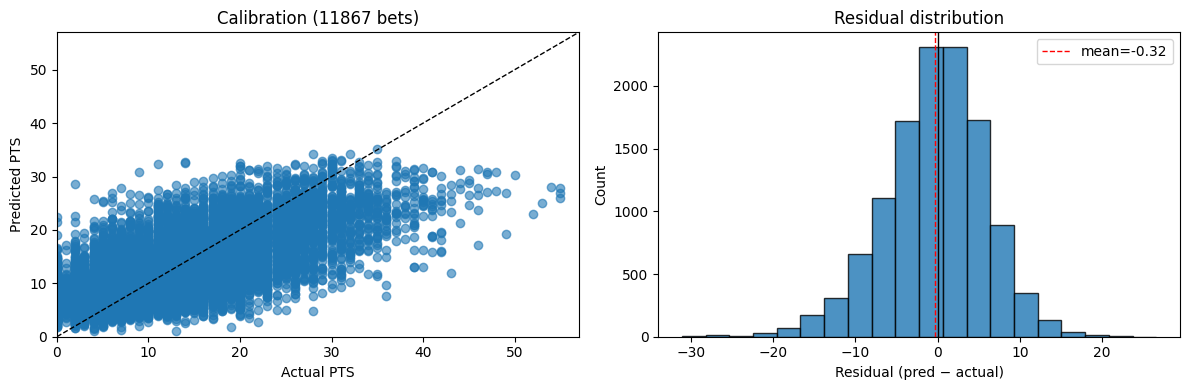

In [28]:
import matplotlib.pyplot as plt

resid = (res["pred points"] - res["actual points"]).astype(float)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
lims = [0, max(res["pred points"].max(), res["actual points"].max()) + 2]
ax.scatter(res["actual points"], res["pred points"], alpha=0.6)
ax.plot(lims, lims, "k--", lw=1)
ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_xlabel("Actual PTS")
ax.set_ylabel("Predicted PTS")
ax.set_title(f"Calibration ({len(res)} bets)")

ax = axes[1]
ax.hist(resid, bins=20, edgecolor="black", alpha=0.8)
ax.axvline(0, color="k", lw=1)
ax.axvline(resid.mean(), color="red", lw=1, ls="--", label=f"mean={resid.mean():.2f}")
ax.set_xlabel("Residual (pred − actual)")
ax.set_ylabel("Count")
ax.set_title("Residual distribution")
ax.legend()

plt.tight_layout(); plt.show()

### Best & worst bets
Top hits with biggest edge (model wins big) and worst misses (model lost big).

In [29]:
tmp = res.copy()
tmp["edge"] = (tmp["pred points"] - tmp["line"]).round(2)
tmp["miss"] = (tmp["pred points"] - tmp["actual points"]).round(2)

print("Biggest edge HITS (model right + confident):")
display(
    tmp[tmp["hit"] == 1]
    .reindex(tmp[tmp["hit"] == 1]["edge"].abs().sort_values(ascending=False).index)
    .head(10)
)

print("\nBiggest edge MISSES (model wrong + confident):")
display(
    tmp[tmp["hit"] == 0]
    .reindex(tmp[tmp["hit"] == 0]["edge"].abs().sort_values(ascending=False).index)
    .head(10)
)

Biggest edge HITS (model right + confident):


,date,player,pred points,side,line,actual points,error,hit,edge,miss
11736,2026-04-10,Jaime Jaquez Jr.,14.687177,Under,24.5,23,8.312823,1,-9.81,-8.31
1898,2025-11-25,Jalen Suggs,15.092951,Under,24.5,4,11.092951,1,-9.41,11.09
415,2025-11-05,Darius Garland,5.201675,Under,14.5,8,2.798325,1,-9.30,-2.80
8046,2026-02-22,Joan Beringer,1.328786,Under,10.5,7,5.671214,1,-9.17,-5.67
331,2025-11-05,Ajay Mitchell,18.613206,Over,10.5,21,2.386794,1,8.11,-2.39
1249,2025-11-17,Paul George,4.521335,Under,12.5,9,4.478665,1,-7.98,-4.48
11732,2026-04-10,Rui Hachimura,11.615074,Under,19.5,13,1.384926,1,-7.88,-1.38
2389,2025-12-02,Jared McCain,7.796492,Under,15.5,14,6.203508,1,-7.70,-6.20
11778,2026-04-12,Kenrich Williams,7.986500,Under,15.5,13,5.013500,1,-7.51,-5.01
11710,2026-04-10,Stephen Curry,22.341991,Under,29.5,11,11.341991,1,-7.16,11.34



Biggest edge MISSES (model wrong + confident):


,date,player,pred points,side,line,actual points,error,hit,edge,miss
11787,2026-04-12,Nae'Qwan Tomlin,9.388095,Under,19.5,26,16.611905,0,-10.11,-16.61
529,2025-11-08,De'Aaron Fox,4.923032,Under,14.5,24,19.076968,0,-9.58,-19.08
4445,2026-01-02,Giannis Antetokounmpo,21.156261,Under,29.5,30,8.843739,0,-8.34,-8.84
10958,2026-03-31,Dillon Brooks,22.302179,Over,14.5,9,13.302179,0,7.80,13.30
4985,2026-01-09,Jalen Williams,18.622566,Under,25.5,26,7.377434,0,-6.88,-7.38
3278,2025-12-18,Jordan Clarkson,9.685174,Under,16.5,18,8.314826,0,-6.81,-8.31
1879,2025-11-25,LeBron James,13.722185,Under,20.5,25,11.277815,0,-6.78,-11.28
8221,2026-02-24,Dejounte Murray,4.938104,Under,11.5,13,8.061896,0,-6.56,-8.06
1875,2025-11-25,Jared McCain,6.011685,Under,12.5,15,8.988315,0,-6.49,-8.99
10203,2026-03-21,Pascal Siakam,23.829626,Over,17.5,14,9.829626,0,6.33,9.83
